# Plot PCA Evaluation

In [106]:
import os


import torch

import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

# import pandas
import pandas as pd
import seaborn as sns


import gc


while not os.path.exists("ldm"):
    %cd ..
assert os.path.exists("ldm")



DEV = "cuda:0" if torch.cuda.is_available() else "cpu"
torch.cuda.empty_cache()
gc.collect()

print(f"Memory Allocated: {torch.cuda.memory_allocated(DEV) / 1024**3:.2f} GB")
print(f"Memory Cached: {torch.cuda.memory_reserved(DEV) / 1024**3:.2f} GB")

Memory Allocated: 0.00 GB
Memory Cached: 0.00 GB


In [107]:
results_dir = "ldm/evaluation/plots/results/Preliminary_LinearProbing"
# Style
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Cambria", "Times New Roman", "DejaVu Serif"]
plt.rcParams["axes.facecolor"] = "#f5f5f5"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["grid.linestyle"] = ":"
plt.rcParams["grid.color"] = "grey"
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["figure.figsize"] = (10, 6)

## Utils

In [83]:
def plot_probe_comparison_grid(json_path, log_path="test_outputs"):
    """
    Generate a grid of violin+box plots to compare validation accuracies
    across different probe types and PCA dimensions.

    Args:
        json_path (str or Path): Path to JSON file containing evaluation results.
        log_path (str or Path): Directory to save the output plot.
    """
    import json
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    # --- Load and flatten data ---
    with open(json_path, "r") as f:
        data = json.load(f)

    flat_records = []
    for model in data:
        for res in model["Results"]:
            for acc in res["ValAccuracies"]:
                flat_records.append(
                    {
                        "Model": model["Model"],
                        "Beta": model["Beta"],
                        "SourceTimestep": model.get(
                            "SourceTimestep", model.get("Source_TS")
                        ),
                        "TargetTimestep": model.get(
                            "TargetTimestep", model.get("Target_TS")
                        ),
                        "ProbeType": res["ProbeType"],
                        "PCA": res["PCA"],
                        "ValAccuracy": acc,
                    }
                )

    df = pd.DataFrame(flat_records)
    df["Beta"] = pd.to_numeric(df["Beta"], errors="coerce")
    df["PCA"] = pd.to_numeric(df["PCA"], downcast="integer")
    df["ValAccuracy"] = pd.to_numeric(df["ValAccuracy"], errors="coerce")

    beta_order = sorted(df["Beta"].dropna().unique())
    pca_order = sorted(df["PCA"].dropna().unique())
    probe_order = ["Linear", "Two-Layer"]

    # --- Plot styling ---
    sns.set_theme(style="darkgrid")
    plt.rcParams.update(
        {
            "font.family": "serif",
            "text.usetex": False,
            "axes.facecolor": "#e8ecf0",
            "axes.edgecolor": "#cccccc",
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "grid.linestyle": "--",
            "grid.alpha": 0.4,
            "lines.linewidth": 1.2,
        }
    )

    # --- Compute y-limits per ProbeType (i.e., per row) ---
    row_y_limits = (
        df.groupby("ProbeType")["ValAccuracy"]
        .max()
        .apply(lambda v: min(1.5, v * 1.5))  # Clamp to 1.2 max
        .to_dict()
    )

    # --- FacetGrid setup ---
    g = sns.FacetGrid(
        df,
        row="ProbeType",
        col="PCA",
        height=2.8,
        aspect=1.2,
        sharey=False,
        row_order=probe_order,
        col_order=pca_order,
        margin_titles=True,
    )

    # --- Drawing function ---
    def draw_boxplot_with_medians(data, **kwargs):
        ax = plt.gca()
        probe_type = data["ProbeType"].iloc[0]
        ax.set_facecolor("#e8ecf0")

        group_counts = data.groupby("Beta")["ValAccuracy"].count()
        has_multiple = group_counts.min() > 1

        if has_multiple and data["ValAccuracy"].count() > 1:
            sns.violinplot(
                data=data,
                x="Beta",
                y="ValAccuracy",
                ax=ax,
                order=beta_order,
                inner=None,
                linewidth=0,
                color="#a0aab8",
                saturation=0.3,
            )
        else:
            sns.stripplot(
                data=data,
                x="Beta",
                y="ValAccuracy",
                ax=ax,
                order=beta_order,
                color="black",
                size=5,
            )

        sns.boxplot(
            data=data,
            x="Beta",
            y="ValAccuracy",
            width=0.3,
            ax=ax,
            order=beta_order,
            color="white",
            fliersize=1.5,
            linewidth=0.7,
            boxprops={"facecolor": "white", "edgecolor": "#333", "zorder": 2},
            whiskerprops={"linewidth": 0.7},
            capprops={"linewidth": 0.7},
            medianprops={"color": "black", "linewidth": 1},
        )

        medians = (
            data.groupby("Beta", observed=True)["ValAccuracy"]
            .median()
            .reindex(beta_order)
        )
        x_vals = list(range(len(beta_order)))
        ax.plot(x_vals, medians.values, color="red", linewidth=1.3, zorder=3)

        ax.set_xticks(x_vals)
        ax.set_xticklabels([f"{b:.4g}" for b in beta_order])
        ax.set_xlabel(r"$\beta$", fontsize=10)
        ax.set_ylabel("Validation Accuracy", fontsize=10)

        # Set consistent y-limit per row
        ylim = row_y_limits.get(probe_type, 1.0)
        ax.set_ylim(0, ylim)
        ax.grid(True, linestyle="--", alpha=0.4)

    # --- Draw the plots ---
    g.map_dataframe(draw_boxplot_with_medians)
    g.set_titles(col_template="PCA = {col_name}", row_template="", size=10)

    # --- Row annotations ---
    row_labels = {
        "Linear": "(a) Linear Probe Classifier Evaluation",
        "Two-Layer": "(b) Two-Layer Probe Classifier Evaluation",
    }
    row_offsets = {"Linear": 0.05, "Two-Layer": 0.08}

    g.fig.subplots_adjust(top=0.92, hspace=0.35)
    for i, probe in enumerate(probe_order):
        row_axes = g.axes[i]
        left = row_axes[0].get_position().x0
        right = row_axes[-1].get_position().x1
        center_x = (left + right) / 2
        bottom_y = min(ax.get_position().y0 for ax in row_axes)
        y_offset = row_offsets[probe]
        g.fig.text(
            center_x,
            bottom_y - y_offset,
            row_labels[probe],
            fontsize=11,
            fontweight="bold",
            ha="center",
            va="top",
        )

    # --- Save and show plot ---
    plot_path = Path(log_path) / "combined_probe_accuracy_grid.png"
    plot_path.parent.mkdir(parents=True, exist_ok=True)
    plt.suptitle(
        "Validation Accuracy over Number of PCA Components", fontsize=14, y=1.05
    )
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved unified comparison plot to: {plot_path}")
    plt.show()
    plt.close()


def plot_pca_comparison_by_beta_grid(json_path, log_path="test_outputs"):
    import json
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    # --- Load data ---
    with open(json_path, "r") as f:
        data = json.load(f)

    # --- Flatten records ---
    flat_records = []
    for model in data:
        for res in model["Results"]:
            for acc in res["ValAccuracies"]:
                flat_records.append(
                    {
                        "Model": model["Model"],
                        "Beta": model["Beta"],
                        "SourceTimestep": model["SourceTimestep"],
                        "TargetTimestep": model["TargetTimestep"],
                        "ProbeType": res["ProbeType"],
                        "PCA": res["PCA"],
                        "ValAccuracy": acc,
                    }
                )

    df = pd.DataFrame(flat_records)
    df["Beta"] = pd.to_numeric(df["Beta"], errors="coerce")
    df["PCA"] = pd.to_numeric(df["PCA"], errors="coerce", downcast="integer")
    df["ValAccuracy"] = pd.to_numeric(df["ValAccuracy"], errors="coerce")

    probe_order = ["Linear", "Two-Layer"]
    beta_order = sorted(df["Beta"].dropna().unique())
    pca_order = sorted(df["PCA"].dropna().unique())

    # --- Style ---
    sns.set_theme(style="darkgrid")
    plt.rcParams.update(
        {
            "font.family": "serif",
            "text.usetex": False,
            "axes.facecolor": "#e8ecf0",
            "axes.edgecolor": "#cccccc",
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "grid.linestyle": "--",
            "grid.alpha": 0.4,
            "lines.linewidth": 1.2,
        }
    )

    y_limits = {
        probe: (
            df[df["ProbeType"] == probe]["ValAccuracy"].min(),
            df[df["ProbeType"] == probe]["ValAccuracy"].max(),
        )
        for probe in probe_order
    }

    g = sns.FacetGrid(
        df,
        row="ProbeType",
        col="Beta",
        height=2.8,
        aspect=1.2,
        sharey=False,
        row_order=probe_order,
        col_order=beta_order,
        margin_titles=True,
    )

    def draw_pca_vs_accuracy_boxplot(data, **kwargs):
        data = data.copy()
        data["PCA"] = pd.to_numeric(data["PCA"], errors="coerce")
        data["ValAccuracy"] = pd.to_numeric(data["ValAccuracy"], errors="coerce")
        probe_type = data["ProbeType"].iloc[0]
        ax = plt.gca()
        ax.set_facecolor("#e8ecf0")

        group_counts = data.groupby("PCA")["ValAccuracy"].count()
        has_multiple = group_counts.min() > 1

        if has_multiple and data["ValAccuracy"].count() > 1:
            sns.violinplot(
                data=data,
                x="PCA",
                y="ValAccuracy",
                ax=ax,
                order=pca_order,
                inner=None,
                linewidth=0,
                color="#a0aab8",
                saturation=0.3,
            )
        else:
            sns.stripplot(
                data=data,
                x="PCA",
                y="ValAccuracy",
                ax=ax,
                order=pca_order,
                color="black",
                size=5,
            )

        sns.boxplot(
            data=data,
            x="PCA",
            y="ValAccuracy",
            width=0.3,
            ax=ax,
            order=pca_order,
            color="white",
            fliersize=1.5,
            linewidth=0.7,
            boxprops={"facecolor": "white", "edgecolor": "#333", "zorder": 2},
            whiskerprops={"linewidth": 0.7},
            capprops={"linewidth": 0.7},
            medianprops={"color": "black", "linewidth": 1},
        )

        medians = (
            data.groupby("PCA", observed=True)["ValAccuracy"]
            .median()
            .reindex(pca_order)
        )
        x_vals = list(range(len(pca_order)))
        y_vals = medians.values
        ax.plot(x_vals, y_vals, color="red", linewidth=1.3, zorder=3)

        ax.set_xticks(x_vals)
        ax.set_xticklabels([str(x) for x in pca_order])
        ax.set_xlabel("PCA Components", fontsize=10)
        ax.set_ylabel("Validation Accuracy", fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.4)

        y_min, y_max = y_limits[probe_type]
        padding = (y_max - y_min) * 0.1 if y_max > y_min else 0.05
        ax.set_ylim(y_min - padding, y_max + padding)

    g.map_dataframe(draw_pca_vs_accuracy_boxplot)
    g.set_titles(col_template=r"$\beta$ = {col_name}", row_template="", size=10)

    row_labels = {
        "Linear": "(a) Linear Probe Classifier Evaluation",
        "Two-Layer": "(b) Two-Layer Probe Classifier Evaluation",
    }
    g.fig.subplots_adjust(top=0.92, hspace=0.35)

    for i, probe in enumerate(probe_order):
        row_axes = g.axes[i]
        left = row_axes[0].get_position().x0
        right = row_axes[-1].get_position().x1
        center_x = (left + right) / 2
        bottom_y = min(ax.get_position().y0 for ax in row_axes)
        y_offset = 0.10 if i == len(probe_order) - 1 else 0.035
        g.fig.text(
            center_x,
            bottom_y - y_offset,
            row_labels[probe],
            fontsize=11,
            fontweight="bold",
            ha="center",
            va="top",
        )

    plt.suptitle(
        "Validation Accuracy across PCA Dimensions per Beta Value", fontsize=14, y=1.05
    )
    plot_path = Path(f"{log_path}/pca_vs_beta_combined_grid.png")
    plot_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved combined PCA/Beta grid plot to: {plot_path}")
    plt.show()
    plt.close()

## Load Data

In [84]:
from pathlib import Path
import json

json_path = "results/pca_evaluation/2025-07-27_14-31-02/PCA_Quantitative_Varying_Beta_Denoising/group_probe_results.json"
log_path = "results/PCA_Quantitative_Eval/logs"

mkdir_path = Path(log_path)
mkdir_path.mkdir(parents=True, exist_ok=True)

with open(json_path, "r") as f:
    data = json.load(f)

flat_records = []
for model in data:
    for res in model["Results"]:
        for acc in res["ValAccuracies"]:
            flat_records.append(
                {
                    "Model": model["Model"],
                    "Beta": model["Beta"],
                    "SourceTimestep": model["SourceTimestep"],
                    "TargetTimestep": model["TargetTimestep"],
                    "ProbeType": res["ProbeType"],
                    "PCA": res["PCA"],
                    "ValAccuracy": acc,
                }
            )

df = pd.DataFrame(flat_records)
df["Beta"] = df["Beta"].astype(float)
df["PCA"] = df["PCA"].astype(int)
df["ValAccuracy"] = df["ValAccuracy"].astype(float)


print(df.head())
print(df.dtypes)

             Model    Beta  SourceTimestep  TargetTimestep ProbeType  PCA  \
0  Beta02x10x_1e4b  0.0001             0.2             1.0    Linear    2   
1  Beta02x10x_1e4b  0.0001             0.2             1.0    Linear    2   
2  Beta02x10x_1e4b  0.0001             0.2             1.0    Linear    2   
3  Beta02x10x_1e4b  0.0001             0.2             1.0    Linear    2   
4  Beta02x10x_1e4b  0.0001             0.2             1.0    Linear    2   

   ValAccuracy  
0     0.011933  
1     0.012287  
2     0.011756  
3     0.011756  
4     0.013823  
Model              object
Beta              float64
SourceTimestep    float64
TargetTimestep    float64
ProbeType          object
PCA                 int64
ValAccuracy       float64
dtype: object


In [85]:
print(df.describe())

               Beta  SourceTimestep  TargetTimestep           PCA  \
count  17020.000000    1.702000e+04         17020.0  17020.000000   
mean       1.874358    2.000000e-01             1.0     23.148179   
std        1.716965    5.318125e-14             0.0     15.295008   
min        0.000100    2.000000e-01             1.0      2.000000   
25%        0.500000    2.000000e-01             1.0      9.000000   
50%        1.000000    2.000000e-01             1.0     20.000000   
75%        3.000000    2.000000e-01             1.0     30.000000   
max        5.000000    2.000000e-01             1.0     50.000000   

        ValAccuracy  
count  17020.000000  
mean       0.410175  
std        0.281376  
min        0.006971  
25%        0.152041  
50%        0.362211  
75%        0.614249  
max        0.999705  


In [86]:
df.groupby(["ProbeType", "PCA"])["ValAccuracy"].describe()

count      mean       std       min       25%       50%  \
ProbeType PCA                                                             
Linear    2     329.0  0.025165  0.006637  0.006971  0.020321  0.025579   
          5     247.0  0.037991  0.010668  0.008743  0.031752  0.039048   
          9     255.0  0.054254  0.015042  0.012228  0.043803  0.059960   
          15    297.0  0.081783  0.026178  0.011342  0.063032  0.087252   
          20    306.0  0.101198  0.029394  0.014709  0.089822  0.106776   
          30    369.0  0.120183  0.027901  0.018254  0.109995  0.132089   
          50    581.0  0.146633  0.029198  0.021030  0.138705  0.151288   
Two-Layer 2     297.0  0.037730  0.005846  0.020203  0.033318  0.038516   
          5    1403.0  0.111115  0.032067  0.026701  0.085864  0.111590   
          9    2485.0  0.236060  0.070032  0.037984  0.183542  0.247932   
          15   2013.0  0.356349  0.100259  0.042474  0.298913  0.371810   
          20   2505.0  0.473988  0.132006  0.045900  0.405423  0.497342   
          30   3391.0  0.680616  0.211234  0.052576  0.549031  0.713079   
          50   2542.0  0.707528  0.233550  0.067462  0.557124  0.731274   

                    75%       max  
ProbeType PCA                      
Linear    2    0.029301  0.036803  
          5    0.047554  0.053934  
          9    0.066163  0.071007  
          15   0.103025  0.113126  
          20   0.126625  0.134983  
          30   0.139355  0.146444  
          50   0.167888  0.178580  
Two-Layer 2    0.042651  0.049327  
          5    0.134599  0.186555  
          9    0.295546  0.341801  
          15   0.429702  0.526819  
          20   0.567758  0.692994  
          30   0.857012  0.977670  
          50   0.904950  0.999705

In [87]:
df.groupby(["ProbeType", "PCA"])["ValAccuracy"].describe()

count      mean       std       min       25%       50%  \
ProbeType PCA                                                             
Linear    2     329.0  0.025165  0.006637  0.006971  0.020321  0.025579   
          5     247.0  0.037991  0.010668  0.008743  0.031752  0.039048   
          9     255.0  0.054254  0.015042  0.012228  0.043803  0.059960   
          15    297.0  0.081783  0.026178  0.011342  0.063032  0.087252   
          20    306.0  0.101198  0.029394  0.014709  0.089822  0.106776   
          30    369.0  0.120183  0.027901  0.018254  0.109995  0.132089   
          50    581.0  0.146633  0.029198  0.021030  0.138705  0.151288   
Two-Layer 2     297.0  0.037730  0.005846  0.020203  0.033318  0.038516   
          5    1403.0  0.111115  0.032067  0.026701  0.085864  0.111590   
          9    2485.0  0.236060  0.070032  0.037984  0.183542  0.247932   
          15   2013.0  0.356349  0.100259  0.042474  0.298913  0.371810   
          20   2505.0  0.473988  0.132006  0.045900  0.405423  0.497342   
          30   3391.0  0.680616  0.211234  0.052576  0.549031  0.713079   
          50   2542.0  0.707528  0.233550  0.067462  0.557124  0.731274   

                    75%       max  
ProbeType PCA                      
Linear    2    0.029301  0.036803  
          5    0.047554  0.053934  
          9    0.066163  0.071007  
          15   0.103025  0.113126  
          20   0.126625  0.134983  
          30   0.139355  0.146444  
          50   0.167888  0.178580  
Two-Layer 2    0.042651  0.049327  
          5    0.134599  0.186555  
          9    0.295546  0.341801  
          15   0.429702  0.526819  
          20   0.567758  0.692994  
          30   0.857012  0.977670  
          50   0.904950  0.999705

2025-08-01 21:16:52,662 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:16:52,672 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:16:52,674 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:16:52,976 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:16:52,982 - INFO - Using categorical units to plot a list of strings that are all parsable as 

[INFO] Saved unified comparison plot to: results/PCA_Quantitative_Eval/logs/combined_probe_accuracy_grid.png


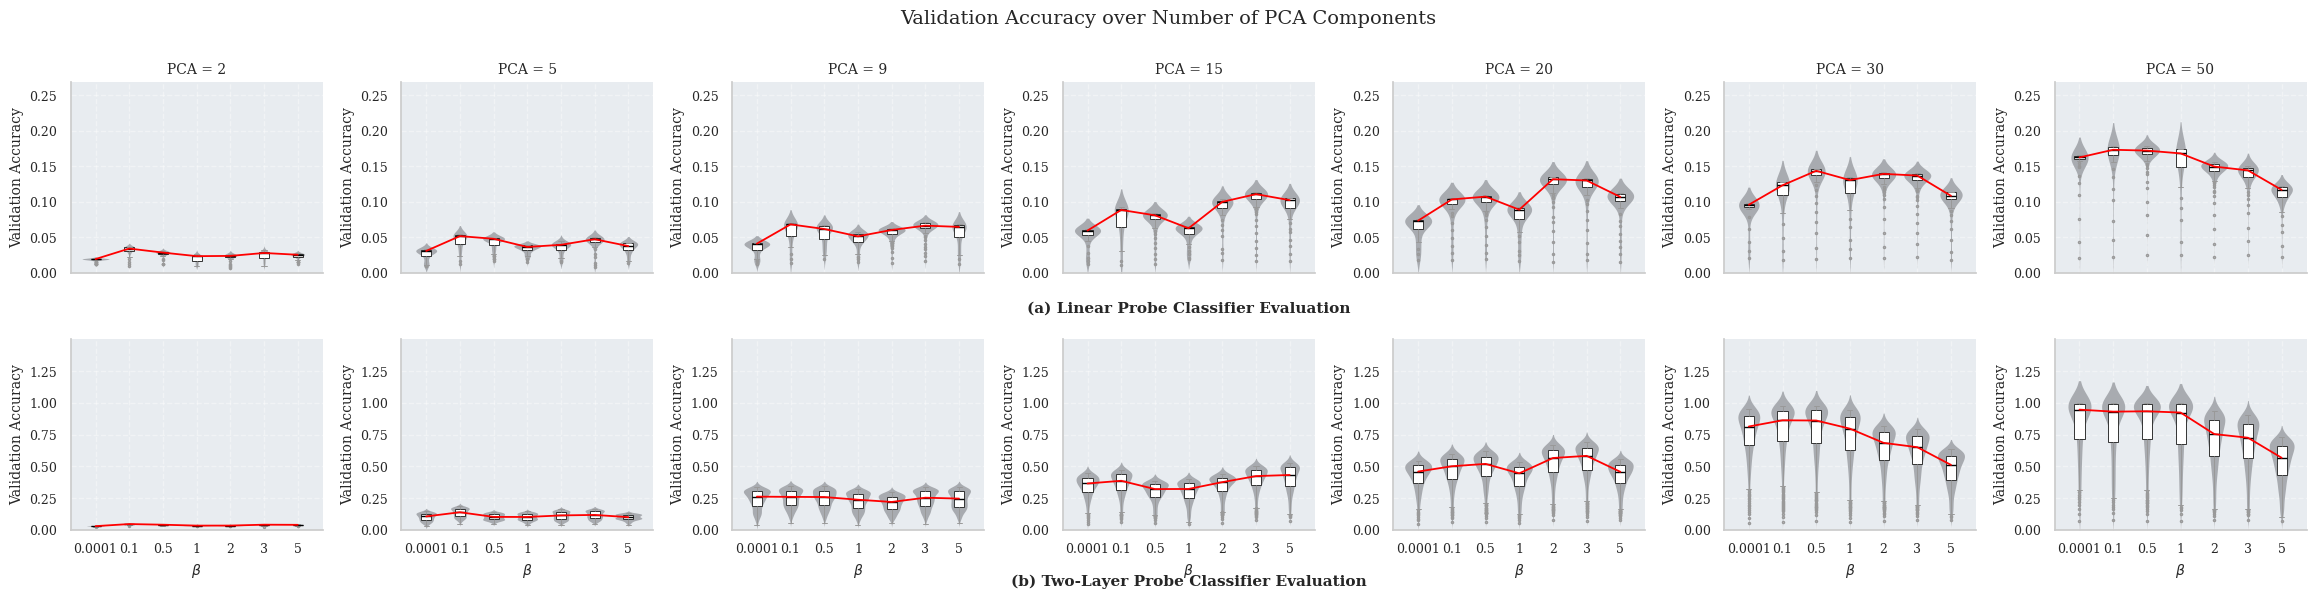

In [88]:
plot_probe_comparison_grid(json_path, log_path)

2025-08-01 21:17:03,097 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:17:03,106 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:17:03,108 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:17:03,389 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:17:03,398 - INFO - Using categorical units to plot a list of strings that are all parsable as 

[INFO] Saved combined PCA/Beta grid plot to: results/PCA_Quantitative_Eval/logs/pca_vs_beta_combined_grid.png


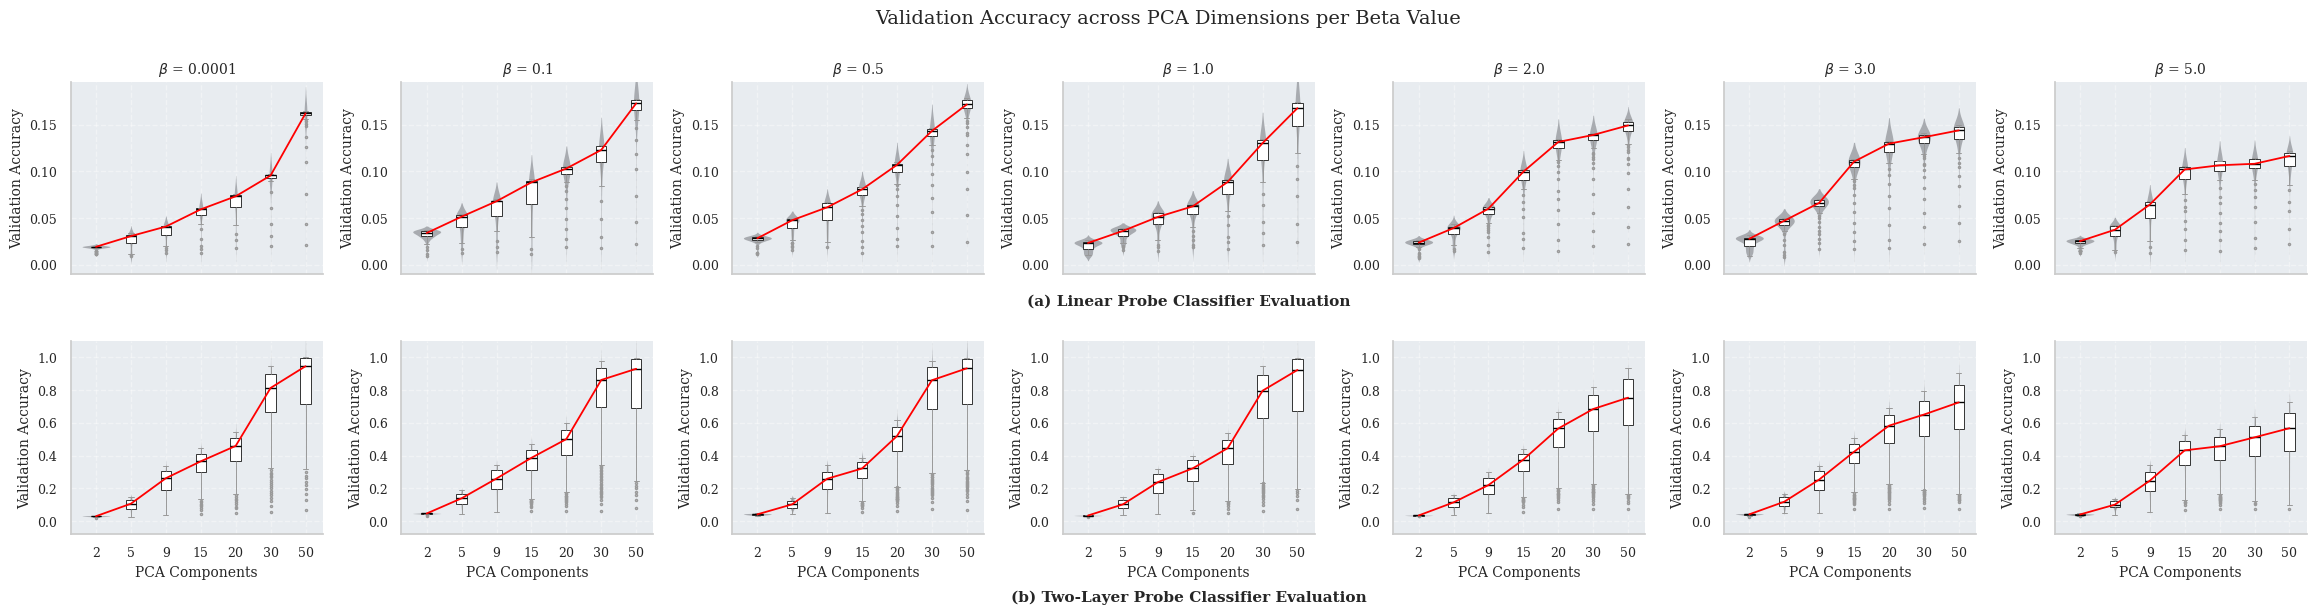

In [89]:
plot_pca_comparison_by_beta_grid(json_path, log_path)

In [90]:
def plot_probe_grid_with_baseline(
    probe_type, df_baseline, df_rest, beta_grid, pca_order
):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    # --- Ensure percentages ---
    df_baseline = df_baseline.copy()
    df_rest = df_rest.copy()

    if df_baseline["ValAccuracy"].max() <= 1.0:
        df_baseline["ValAccuracy"] *= 100
    if df_rest["ValAccuracy"].max() <= 1.0:
        df_rest["ValAccuracy"] *= 100

    # --- Config ---
    n_betas_to_plot = 9
    n_rows, n_cols = 3, 4
    fig = plt.figure(figsize=(18, 9))
    gs = gridspec.GridSpec(
        nrows=n_rows, ncols=n_cols, width_ratios=[1.5, 1, 1, 1], wspace=0.4, hspace=0.5
    )
    palette = "Blues" if probe_type == "Linear" else "Reds"

    # --- Baseline plot ---
    ax_main = fig.add_subplot(gs[0:2, 0])
    sns.violinplot(
        data=df_baseline,
        x="PCA",
        y="ValAccuracy",
        ax=ax_main,
        order=pca_order,
        palette=palette,
        linewidth=1.2,
        saturation=0.85,
        inner="box",
    )
    med = df_baseline.groupby("PCA")["ValAccuracy"].median().reindex(pca_order)
    ax_main.plot(
        range(len(pca_order)), med.values, color="black", linewidth=1.2, linestyle="--"
    )
    ax_main.set_title(r"$\beta = 1.0$ (Baseline)", fontsize=12, fontweight="bold")
    ax_main.set_xlabel("PCA Components")
    ax_main.set_ylabel("Validation Accuracy (%)")
    ax_main.grid(True, linestyle="--", alpha=0.4)

    # Get unified y-limits (including values > 100 if present)
    y_min, y_max = ax_main.get_ylim()

    # --- Other β plots ---
    betas_to_plot = [b for b in beta_grid if b != 1.0][:n_betas_to_plot]
    for idx, beta in enumerate(betas_to_plot):
        row = idx // 3
        col = (idx % 3) + 1
        ax = fig.add_subplot(gs[row, col])

        subset = df_rest[
            (df_rest["ProbeType"] == probe_type) & (df_rest["Beta"] == beta)
        ]
        sns.violinplot(
            data=subset,
            x="PCA",
            y="ValAccuracy",
            ax=ax,
            order=pca_order,
            palette=palette,
            linewidth=1.2,
            saturation=0.85,
            inner="box",
        )
        med = subset.groupby("PCA")["ValAccuracy"].median().reindex(pca_order)
        ax.plot(
            range(len(pca_order)),
            med.values,
            color="black",
            linewidth=1.2,
            linestyle="--",
        )

        ax.set_title(rf"$\beta$ = {beta:.3g}", fontsize=10)
        ax.set_xlabel("PCA")
        ax.set_ylabel("Accuracy (%)" if col == 1 else "")
        ax.set_ylim(y_min, y_max)  # consistent y-limits
        ax.grid(True, linestyle="--", alpha=0.4)

    fig.suptitle(
        f"{probe_type} Probe: Validation Accuracy across PCA Dimensions by $\\beta$",
        fontsize=15,
        y=1.02,
    )
    plt.tight_layout()
    return fig


def plot_probe_grid_across_timesteps(df, probe_type, save_dir):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    timestep_labels = sorted(df["TimestepLabel"].unique())
    beta_grid = sorted(df["Beta"].unique())
    pca_order = sorted(df["PCA"].unique())

    fig = plt.figure(figsize=(4 * len(beta_grid), 4 * len(timestep_labels)))
    gs = gridspec.GridSpec(
        nrows=len(timestep_labels), ncols=len(beta_grid), wspace=0.4, hspace=0.4
    )

    for i, ts_label in enumerate(timestep_labels):
        for j, beta in enumerate(beta_grid):
            ax = fig.add_subplot(gs[i, j])
            subset = df[
                (df["ProbeType"] == probe_type)
                & (df["TimestepLabel"] == ts_label)
                & (df["Beta"] == beta)
            ]

            if subset.empty:
                ax.axis("off")
                continue

            sns.violinplot(
                data=subset,
                x="PCA",
                y="ValAccuracy",
                ax=ax,
                order=pca_order,
                palette="Blues" if probe_type == "Linear" else "Reds",
                linewidth=1.2,
                saturation=0.85,
                inner="box",
            )

            med = subset.groupby("PCA")["ValAccuracy"].median().reindex(pca_order)
            ax.plot(
                range(len(pca_order)),
                med.values,
                color="black",
                linewidth=1.2,
                linestyle="--",
            )

            ax.set_title(f"$\\beta$={beta}, {ts_label}", fontsize=9)
            ax.set_xlabel("PCA")
            ax.set_ylabel("Accuracy (%)" if j == 0 else "")
            ax.grid(True, linestyle="--", alpha=0.3)

    fig.suptitle(f"{probe_type} Probe: Val Accuracy by β and Timestep", fontsize=16)
    plt.tight_layout()

    out_path = (
        Path(save_dir)
        / f"timestep_probe_grid_{probe_type.lower().replace('-', '')}.png"
    )
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved plot: {out_path}")
    plt.close()


def plot_recon_probe_grid_by_model(df, probe_type, save_path=None):
    import matplotlib.pyplot as plt

    # Normalize probe type values in DataFrame
    df = df.copy()
    df["ProbeType"] = df["ProbeType"].astype(str).str.strip().str.lower()
    probe_type_clean = probe_type.strip().lower()

    # Filter by probe type
    df_plot = df[df["ProbeType"] == probe_type_clean].copy()

    # Convert accuracy to percent if necessary
    if df_plot["ValAccuracy"].max() <= 1.0:
        df_plot["ValAccuracy"] *= 100

    # Restrict to reconstruction models (source == target)
    df_plot = df_plot[df_plot["SourceTimestep"] == df_plot["TargetTimestep"]]

    # Unique reconstruction model keys (e.g. 0.0 → 0.0)
    model_keys = sorted(
        df_plot[["SourceTimestep", "TargetTimestep"]].drop_duplicates().values.tolist()
    )
    pca_order = sorted(df_plot["PCA"].unique())

    # Choose color palette
    palette = "Blues" if probe_type_clean == "linear" else "Reds"

    # Prepare figure
    fig, axes = plt.subplots(
        1, len(model_keys), figsize=(6 * len(model_keys), 5), sharey=True
    )

    if len(model_keys) == 1:
        axes = [axes]  # Ensure iterable if only 1 plot

    for ax, (source_ts, target_ts) in zip(axes, model_keys):
        subset = df_plot[
            (df_plot["SourceTimestep"] == source_ts)
            & (df_plot["TargetTimestep"] == target_ts)
        ]

        if subset.empty:
            ax.axis("off")
            continue

        sns.violinplot(
            data=subset,
            x="PCA",
            y="ValAccuracy",
            ax=ax,
            order=pca_order,
            palette=palette,
            inner="box",
            linewidth=1.2,
            saturation=0.85,
        )

        # Plot medians
        med = subset.groupby("PCA")["ValAccuracy"].median().reindex(pca_order)
        ax.plot(
            range(len(pca_order)),
            med.values,
            color="black",
            linewidth=1.2,
            linestyle="--",
        )

        # Title: t_source → t_target
        label = rf"$\beta$ Model: $t_{{source}} = {source_ts:.2f} \rightarrow t_{{target}} = {target_ts:.2f}$"
        ax.set_title(label, fontsize=12)
        ax.set_xlabel("PCA Components")
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[0].set_ylabel("Validation Accuracy (%)")
    fig.suptitle(
        f"{probe_type.strip().title()} Probe — Reconstruction Models", fontsize=15
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[INFO] Saved plot to: {save_path}")

    plt.show()
    plt.close(fig)

# Evaluation for Denoising

In [93]:
df_baseline = df[df["Beta"] == 1.0]
dfs_baseline = {
    probe: df_baseline[df_baseline["ProbeType"] == probe]
    for probe in df["ProbeType"].unique()
}
dfs_rest = {
    probe: df[(df["ProbeType"] == probe) & (df["Beta"] != 1.0)]
    for probe in df["ProbeType"].unique()
}

beta_grid = sorted(df["Beta"].unique())
pca_order = sorted(df["PCA"].unique())
print(f"Beta grid: {beta_grid}")
print(f"PCA order: {pca_order}")

Beta grid: [0.0001, 0.1, 0.5, 1.0, 2.0, 3.0, 5.0]
PCA order: [2, 5, 9, 15, 20, 30, 50]


# Evaluation for Reconstruction

In [96]:
# === Your JSON file paths ===
json_paths = {
    "0.00x": "results/PCA_Quantitative_Eval/2025-07-31_16-39-48/PCA_Quantitative_All_Beta_Models/Beta00x00x_01b/pca_evaluation_Beta00x00x_01b_imagenet256-dataset-T000006/structured_results.json",
    "0.20x": "results/PCA_Quantitative_Eval/2025-07-31_16-39-48/PCA_Quantitative_All_Beta_Models/Beta02x02x_01b/pca_evaluation_Beta02x02x_01b_imagenet256-dataset-T000006/structured_results.json",
    "0.50x": "results/PCA_Quantitative_Eval/2025-07-31_16-39-48/PCA_Quantitative_All_Beta_Models/Beta05x05x_01b/pca_evaluation_Beta05x05x_01b_imagenet256-dataset-T000006/structured_results.json",
}

for label, path in json_paths.items():
    with open(path, "r") as f:
        data = json.load(f)
        print(type(data))
        if isinstance(data, dict):
            print(data.keys())
        elif isinstance(data, list):
            print(type(data[0]))

<class 'dict'>
dict_keys(['Model', 'Beta', 'Source_TS', 'Target_TS', 'NumSamples', 'NumClasses', 'NumComponents', 'ExplainedVariance', 'ExplainedVarianceRatio', 'CumulativeVarianceRatio', 'PCA_Latent_Stats', 'PC_MutualInformation', 'PC_Entropy', 'Results'])
<class 'dict'>
dict_keys(['Model', 'Beta', 'Source_TS', 'Target_TS', 'NumSamples', 'NumClasses', 'NumComponents', 'ExplainedVariance', 'ExplainedVarianceRatio', 'CumulativeVarianceRatio', 'PCA_Latent_Stats', 'PC_MutualInformation', 'PC_Entropy', 'Results'])
<class 'dict'>
dict_keys(['Model', 'Beta', 'Source_TS', 'Target_TS', 'NumSamples', 'NumClasses', 'NumComponents', 'ExplainedVariance', 'ExplainedVarianceRatio', 'CumulativeVarianceRatio', 'PCA_Latent_Stats', 'PC_MutualInformation', 'PC_Entropy', 'Results'])


In [97]:
import json
import pandas as pd

# === Your JSON file paths ===
json_paths = {
    "0.00x": "results/PCA_Quantitative_Eval/2025-07-31_16-39-48/PCA_Quantitative_All_Beta_Models/Beta00x00x_01b/pca_evaluation_Beta00x00x_01b_imagenet256-dataset-T000006/structured_results.json",
    "0.20x": "results/PCA_Quantitative_Eval/2025-07-31_16-39-48/PCA_Quantitative_All_Beta_Models/Beta02x02x_01b/pca_evaluation_Beta02x02x_01b_imagenet256-dataset-T000006/structured_results.json",
    "0.50x": "results/PCA_Quantitative_Eval/2025-07-31_16-39-48/PCA_Quantitative_All_Beta_Models/Beta05x05x_01b/pca_evaluation_Beta05x05x_01b_imagenet256-dataset-T000006/structured_results.json",
}

records = []

for label, path in json_paths.items():
    with open(path, "r") as f:
        data = json.load(f)

    model_name = data.get("Model", label)
    beta = float(data["Beta"])
    source_ts = float(data.get("SourceTimestep", data.get("Source_TS", -1)))
    target_ts = float(data.get("TargetTimestep", data.get("Target_TS", -1)))

    for res in data["Results"]:
        probe_type = res.get("ProbeType")
        pca_component = res.get("PCA")

        if "ValAccuracies" not in res:
            print(
                f"[WARNING] Skipping missing 'ValAccuracies' in model {model_name}, PCA={pca_component}, Probe={probe_type}"
            )
            continue

        for acc in res["ValAccuracies"]:
            records.append(
                {
                    "Model": model_name,
                    "Beta": beta,
                    "SourceTimestep": source_ts,
                    "TargetTimestep": target_ts,
                    "ProbeType": probe_type,
                    "PCA": int(pca_component),
                    "ValAccuracy": float(acc),
                }
            )

# === Build DataFrame ===
df = pd.DataFrame(records)

# === Inspect ===
print(df.head())
print(df.dtypes)
print(f"[INFO] Loaded {len(df)} rows from {len(json_paths)} models.")

[WARNING] Skipping missing 'ValAccuracies' in model Beta00x00x_01b_imagenet256-dataset-T000006, PCA=2, Probe=SVM
[WARNING] Skipping missing 'ValAccuracies' in model Beta00x00x_01b_imagenet256-dataset-T000006, PCA=2, Probe=LinearSVM
[WARNING] Skipping missing 'ValAccuracies' in model Beta00x00x_01b_imagenet256-dataset-T000006, PCA=2, Probe=MLP
[WARNING] Skipping missing 'ValAccuracies' in model Beta00x00x_01b_imagenet256-dataset-T000006, PCA=3, Probe=SVM
[WARNING] Skipping missing 'ValAccuracies' in model Beta00x00x_01b_imagenet256-dataset-T000006, PCA=3, Probe=LinearSVM
[WARNING] Skipping missing 'ValAccuracies' in model Beta00x00x_01b_imagenet256-dataset-T000006, PCA=3, Probe=MLP
[WARNING] Skipping missing 'ValAccuracies' in model Beta00x00x_01b_imagenet256-dataset-T000006, PCA=5, Probe=SVM
[WARNING] Skipping missing 'ValAccuracies' in model Beta00x00x_01b_imagenet256-dataset-T000006, PCA=5, Probe=LinearSVM
[WARNING] Skipping missing 'ValAccuracies' in model Beta00x00x_01b_imagenet256

In [98]:
print(df["ProbeType"].value_counts())

ProbeType
Two-Layer    1787
Linear        509
Name: count, dtype: int64


In [99]:
df[df["ProbeType"] == "Two-Layer"].describe()

,Beta,SourceTimestep,TargetTimestep,PCA,ValAccuracy
count,1.787000e+03,1787.000000,1787.000000,1787.000000,1787.000000
mean,1.000000e-01,0.237325,0.237325,27.139340,0.340375
std,3.289956e-15,0.212462,0.212462,15.609425,0.237163
min,1.000000e-01,0.000000,0.000000,2.000000,0.017013
25%,1.000000e-01,0.000000,0.000000,15.000000,0.163103
50%,1.000000e-01,0.200000,0.200000,20.000000,0.291529
75%,1.000000e-01,0.500000,0.500000,50.000000,0.473033
max,1.000000e-01,0.500000,0.500000,50.000000,0.997519


In [100]:
df[df["ProbeType"] == "Two-Layer"].groupby("PCA")["ValAccuracy"].mean()

PCA
2     0.028009
3     0.033413
5     0.061476
9     0.112727
15    0.231550
20    0.279732
30    0.406996
50    0.552134
Name: ValAccuracy, dtype: float64

In [101]:
print(df["ProbeType"].unique())

['Linear' 'Two-Layer']


In [102]:
df["ProbeType"] = df["ProbeType"].str.strip().str.replace("_", "-").str.title()
print(df["ProbeType"].unique())

['Linear' 'Two-Layer']


In [103]:
df[df["ProbeType"] == "Two-Layer"].groupby("PCA")["ValAccuracy"].describe()

,count,mean,std,min,25%,50%,75%,max
PCA,,,,,,,,
2,46.0,0.028009,0.005426,0.017013,0.024885,0.028119,0.029950,0.038752
3,41.0,0.033413,0.006218,0.018785,0.029537,0.032786,0.039048,0.043183
5,67.0,0.061476,0.018188,0.018726,0.052487,0.068112,0.073488,0.086661
9,132.0,0.112727,0.040193,0.023039,0.081920,0.106569,0.150062,0.182420
15,294.0,0.231550,0.078061,0.030305,0.178920,0.239012,0.288989,0.372164
20,316.0,0.279732,0.108096,0.028651,0.205709,0.279655,0.336691,0.493088
30,426.0,0.406996,0.183396,0.031782,0.268593,0.385161,0.522610,0.767663
50,465.0,0.552134,0.265345,0.033140,0.354726,0.533837,0.756026,0.997519


In [104]:
df.groupby(["Model", "Beta", "SourceTimestep", "TargetTimestep", "ProbeType"])[
    "ValAccuracy"
].count()

Model                                       Beta  SourceTimestep  TargetTimestep  ProbeType
Beta00x00x_01b_imagenet256-dataset-T000006  0.1   0.0             0.0             Linear       156
                                                                                  Two-Layer    631
Beta02x02x_01b_imagenet256-dataset-T000006  0.1   0.2             0.2             Linear       167
                                                                                  Two-Layer    513
Beta05x05x_01b_imagenet256-dataset-T000006  0.1   0.5             0.5             Linear       186
                                                                                  Two-Layer    643
Name: ValAccuracy, dtype: int64

2025-08-01 21:20:19,762 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2025-08-01 21:20:19,770 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:20:19,772 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:20:20,216 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:20:20,225 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:20:20,227 - INFO - Using categorical units to plot a list of strings that are all parsable as 

[INFO] Saved plot to: linear_recon_grid.png


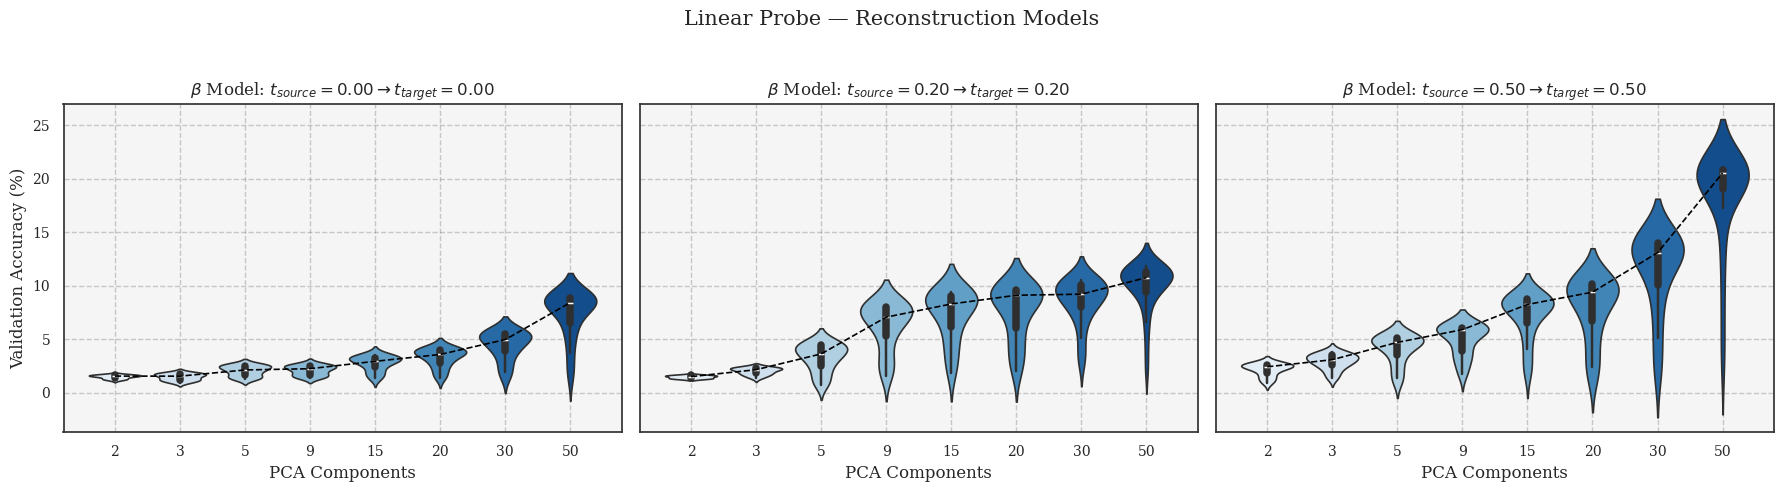

2025-08-01 21:20:22,490 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:20:22,499 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:20:22,501 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:20:22,842 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-01 21:20:22,854 - INFO - Using categorical units to plot a list of strings that are all parsable as 

[INFO] Saved plot to: twolayer_recon_grid.png


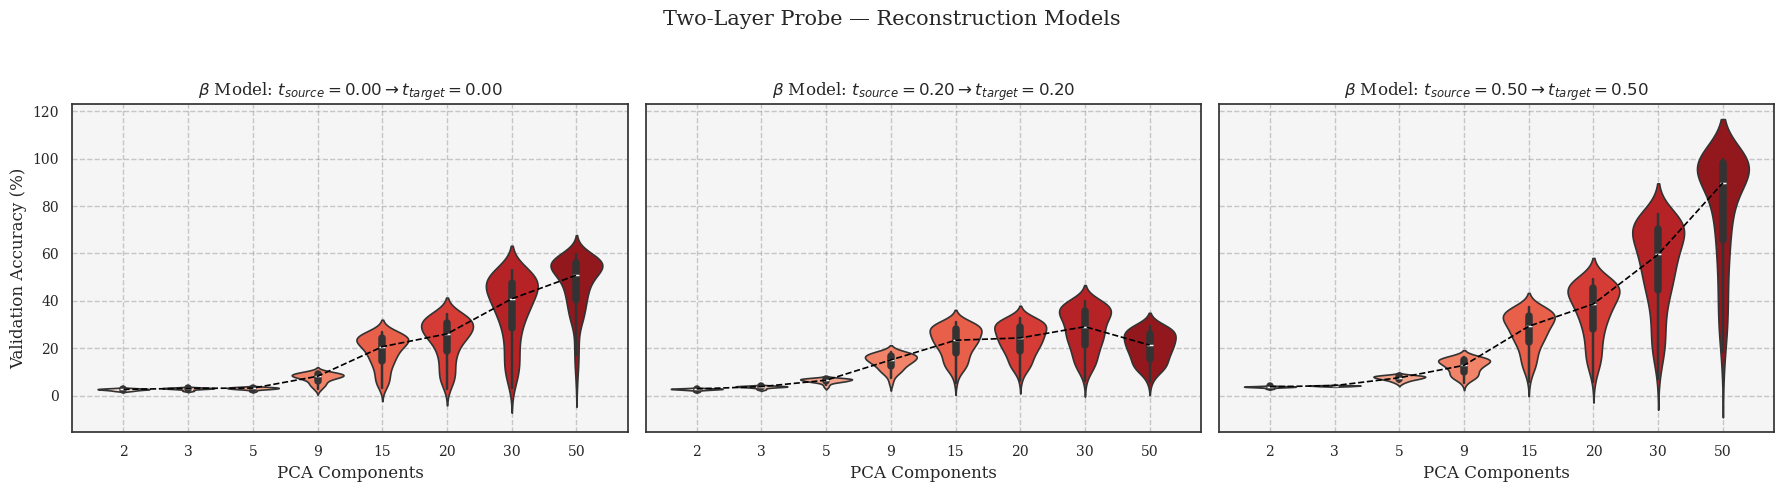

In [108]:
plot_recon_probe_grid_by_model(df, "Linear", save_path="linear_recon_grid.png")
plot_recon_probe_grid_by_model(df, "Two-Layer", save_path="twolayer_recon_grid.png")